In [1]:
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
ages = np.array([22, 38, 26, 35, 35, 28, 54, 2, 
                 27, 14, 4, 58, 20, 39, 14, 55, 
                 2, 31, 35, 34, 15, 28, 8, 38, 19])


In [4]:

print("means", np.mean(ages))

means 27.24


In [5]:
print("Median", np.median(ages))

Median 28.0


In [6]:
print("Std dev ", np.std(ages))

Std dev  15.334353589245293


In [7]:
print("Variance ", np.var(ages))

Variance  235.14239999999998


In [8]:
print("Min" , np.min(ages))

Min 2


In [9]:
print("Max", np.max(ages))

Max 58


In [10]:
print("25th percentile", np.percentile(ages,25))

25th percentile 15.0


In [11]:
print("75th percentile", np.percentile(ages,75))

75th percentile 35.0


In [14]:
print("IQR", np.percentile(ages,75)-np.percentile(ages,25))

IQR 20.0


In [15]:
plt.figure(figsize=(10,4))

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

Text(0.5, 1.0, 'Age Distribution')

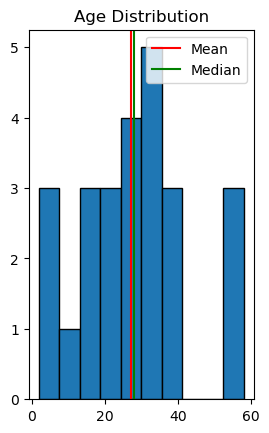

In [16]:
plt.subplot(1,2,1)
plt.hist(ages,bins=10, edgecolor='black')
plt.axvline(np.mean(ages), color='red',label='Mean')
plt.axvline(np.median(ages), color='green',label='Median')
plt.legend()
plt.title('Age Distribution')

# Normal Distribution

In [17]:
np.random.seed(42)

In [18]:
normal_data = np.random.normal(loc=0,scale=1,size=1000)

In [19]:
print("Mean:", round(np.mean(normal_data),3))

Mean: 0.019


In [20]:
print("Std Dev:", round(np.std(normal_data),3))

Std Dev: 0.979


In [21]:
within_1_std = np.sum(np.abs(normal_data) < 1) / len(normal_data)
within_2_std = np.sum(np.abs(normal_data) < 2) / len(normal_data)
within_3_std = np.sum(np.abs(normal_data) < 3) / len(normal_data)

In [22]:
print("\n% within 1 std dev:", round(within_1_std * 100, 1))
print("% within 2 std dev:", round(within_2_std * 100, 1))
print("% within 3 std dev:", round(within_3_std * 100, 1))


% within 1 std dev: 69.8
% within 2 std dev: 95.9
% within 3 std dev: 99.7


Chart saved


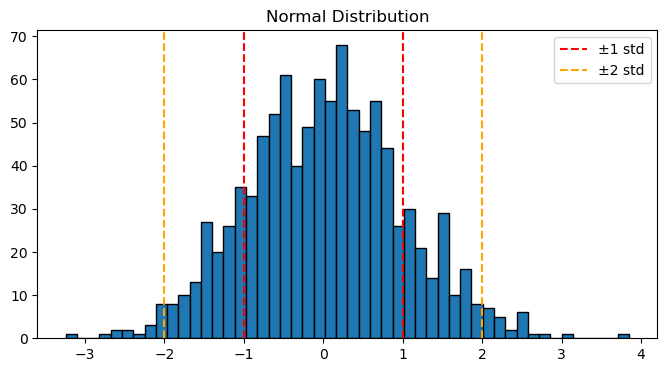

In [23]:
plt.figure(figsize=(8, 4))
plt.hist(normal_data, bins=50, edgecolor='black')
plt.axvline(-1, color='red', linestyle='--', label='±1 std')
plt.axvline(1, color='red', linestyle='--')
plt.axvline(-2, color='orange', linestyle='--', label='±2 std')
plt.axvline(2, color='orange', linestyle='--')
plt.legend()
plt.title('Normal Distribution')
plt.savefig('normal_distribution.png')
print("Chart saved")

# Correlation

In [24]:
import pandas as pd

In [26]:
Tc = pd.read_csv("./titanic/train.csv")
Tc['Age'] = Tc['Age'].fillna(Tc['Age'].median())
Tc['Has_Cabin'] = Tc['Cabin'].apply(lambda x: 0 if pd.isnull(x) else 1)
Tc = Tc.drop('Cabin', axis=1)
Tc['Sex'] = Tc['Sex'].map({'male': 0, 'female': 1})

In [27]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 
            'Parch', 'Fare', 'Has_Cabin']


In [28]:
correlation = Tc[features + ['Survived']].corr()['Survived']

In [29]:
print("Correlation with Survival:" , correlation.sort_values(ascending=False))

Correlation with Survival: Survived     1.000000
Sex          0.543351
Has_Cabin    0.316912
Fare         0.257307
Parch        0.081629
SibSp       -0.035322
Age         -0.064910
Pclass      -0.338481
Name: Survived, dtype: float64


In [30]:
# Correlation findings:
# Sex (0.54)      → strongest predictor
# Pclass (-0.34)  → second strongest (negative)
# Has_Cabin (0.32) → engineered feature beats Fare (0.26)
# Age (-0.06)     → barely matters
#
# Key insight: correlation validates feature engineering
# Has_Cabin > Fare proves missing data contained signal
# Model weights and correlation rankings agree

# Compare survival statistics

In [31]:
survived = Tc[Tc['Survived'] == 1]
died = Tc[Tc['Survived'] == 0]

In [32]:
print("=== SURVIVORS ===")
print("Mean age:", round(survived['Age'].mean(), 1))
print("Mean fare:", round(survived['Fare'].mean(), 1))
print("% female:", round(survived['Sex'].mean() * 100, 1))
print("Mean Pclass:", round(survived['Pclass'].mean(), 1))

print("\n=== DIED ===")
print("Mean age:", round(died['Age'].mean(), 1))
print("Mean fare:", round(died['Fare'].mean(), 1))
print("% female:", round(died['Sex'].mean() * 100, 1))
print("Mean Pclass:", round(died['Pclass'].mean(), 1))

=== SURVIVORS ===
Mean age: 28.3
Mean fare: 48.4
% female: 68.1
Mean Pclass: 2.0

=== DIED ===
Mean age: 30.0
Mean fare: 22.1
% female: 14.8
Mean Pclass: 2.5
